In [7]:
!pip install --upgrade --force-reinstall --no-deps kaggle

^C


In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [ ]:
!python -m pip install matplotlib
import matplotlib.pyplot as plt

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

(27455, 50)
Total Explained Variance: 0.8874


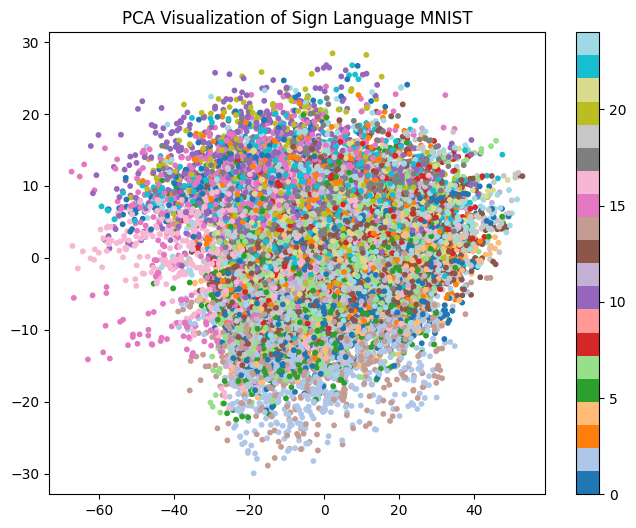

In [ ]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("archive/sign_mnist_train/sign_mnist_train.csv")
X = train_df.drop("label", axis=1).values
y = train_df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"Total Explained Variance: {explained_variance:.4f}")

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap='tab20', s=10)
plt.colorbar()
plt.title("PCA Visualisation of Sign Language MNIST")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


In [ ]:
clf = LogisticRegression(max_iter=1000)
clf = SVC(kernel="rbf")
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.9974503733381898


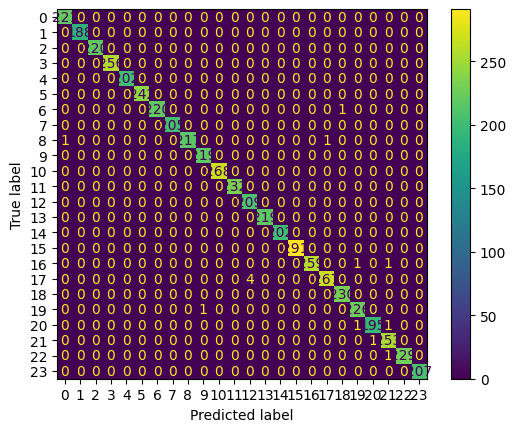

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()